<a href="https://colab.research.google.com/github/sergiomora03/AdvancedTopicsAnalytics/blob/main/notebooks/L27-GraphNeuralNetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Machine Learning



In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import randint

%matplotlib inline

In [2]:
import torch
!pip install -q torch-geometric -f https://data.pyg.org/whl/torch-{torch_version}.html

torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.1 MB/s eta 0:00:00


In [ ]:
from torch_geometric.data.storage import GlobalStorage
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch_geometric.utils import to_dense_adj
from torch_geometric.datasets import FacebookPagePage
from torch_geometric.data import Data
import torch.serialization

## Facebook Page-Page dataset

This dataset was introduced by [Rozemberczki et al. in 2019](https://arxiv.org/abs/1909.13021). It was created using the Facebook Graph API in November 2017. In this dataset, each of the 22,470 nodes represents an official Facebook page. Pages are connected when there are mutual likes between them. Node features (128-dim vectors) are created from textual descriptions written by the owners of these pages. Our goal is to classify each node into one of four categories:

- politicians
- companies
- television shows
- governmental organizations.

The Facebook Page-Page dataset is similar to the previous one: it’s a social network with a node classification task. However, there are three major differences with Cora:

The number of nodes is much higher (2,708 versus 22,470)
The dimensionality of the node features decreased dramatically (from 1,433 to 128)
The goal is to classify each node into four categories instead of seven (which is easier since there are fewer options)
The following figure is a visualization of the dataset using Gephi. First, nodes with few connections have been filtered out to improve performance. The size of the remaining nodes depends on their number of connections, and their color indicates the category they belong to. Finally, two layouts have been applied: Fruchterman-Reingold and ForceAtlas2.

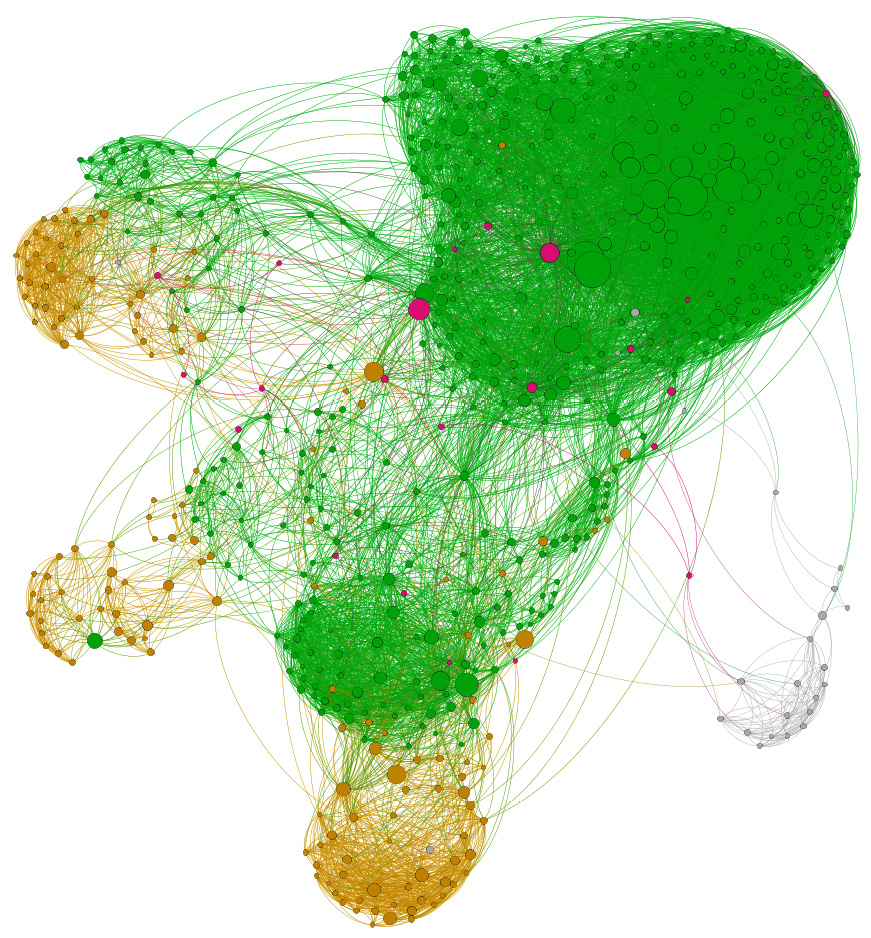

### Load dataset

In [4]:
from torch_geometric.datasets import FacebookPagePage

In [5]:
dataset = FacebookPagePage(root=".")

data = dataset[0]

print(f'Dataset: {dataset}')
print('-----------------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.x.shape[0]}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

print(f'\nGraph:')
print('------')
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

data.train_mask = range(18000)
data.val_mask = range(18001, 20000)
data.test_mask = range(20001, 22470)

Processing...
Done!


Dataset: FacebookPagePage()
-----------------------
Number of graphs: 1
Number of nodes: 22470
Number of features: 128
Number of classes: 4

Graph:
------
Edges are directed: False
Graph has isolated nodes: False
Graph has loops: True


## Visualizing the graph

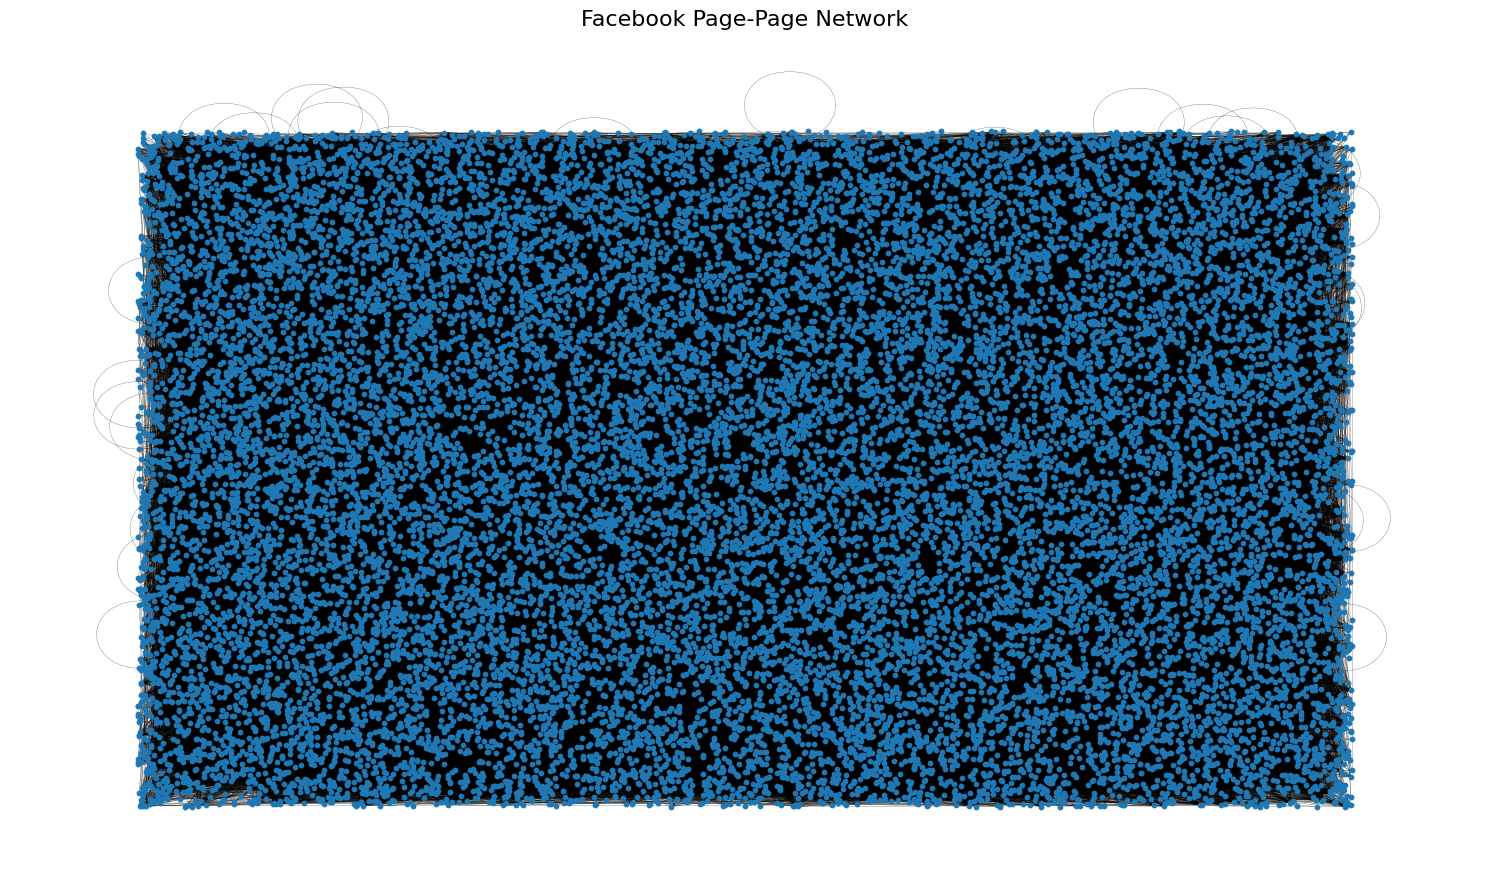

In [6]:
edge_index_list = pd.DataFrame(data.edge_index.numpy().T, columns=['start_node','end_node'])

G = nx.from_pandas_edgelist(edge_index_list, "start_node", "end_node")

fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")

plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}

nx.draw_networkx(G, pos=nx.random_layout(G), ax=ax, **plot_options)
plt.title("Facebook Page-Page Network", fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
import json

In [8]:
nodes_data = []
for node_id in range(min(5000, data.num_nodes)):
    if node_id < len(data.y):
        group = int(data.y[node_id].item())
    else:
        group = 0

    nodes_data.append({
        "id": str(node_id),
        "group": group
    })

edges_data = []
for edge in edge_index_list.values:
    source, target = edge
    if source < 5000 and target < 5000:
        edges_data.append({
            "source": str(source),
            "target": str(target)
        })

graph_data = {
    "nodes": nodes_data,
    "links": edges_data
}

graph_json = json.dumps(graph_data)

from IPython.display import HTML

html_code = f"""
<!DOCTYPE html>
<html>
<head>
    <style> body {{ margin: 0; }} </style>
    <script src="https://unpkg.com/3d-force-graph@1.70.5/dist/3d-force-graph.min.js"></script>
</head>
<body>
    <div id="3d-graph" style="width: 100%; height: 600px;"></div>

    <script>
        // Parse the data
        const graphData = {graph_json};

        // Node colors based on group
        const colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'];

        // Initialize the 3D force graph
        const Graph = ForceGraph3D()
            (document.getElementById('3d-graph'))
            .graphData(graphData)
            .nodeColor(node => colors[node.group % colors.length])
            .nodeRelSize(3)
            .linkWidth(0.2)
            .linkOpacity(0.5)
            .backgroundColor('#FFFFFF')
            .nodeLabel(node => `Node ${{node.id}}`)
            .linkDirectionalParticles(1)
            .linkDirectionalParticleWidth(0.5)
            .enableNodeDrag(true)
            .enableNavigationControls(true)
            .showNavInfo(true);

        // Handle window resize
        window.addEventListener('resize', () => {{
            Graph.width(document.getElementById('3d-graph').clientWidth)
                .height(document.getElementById('3d-graph').clientHeight);
        }});

        // Instructions
        console.log("Navigation controls: Left-click + drag to rotate, right-click + drag to pan, scroll to zoom");
    </script>
</body>
</html>
"""

HTML(html_code)

### Split dataset

In [9]:
# Dataset
dataset = FacebookPagePage(root='/tmp/Facebook')
data = dataset[0]
data.train_mask = range(18000)
data.val_mask = range(18001, 20000)
data.test_mask = range(20001, 22470)

Processing...
Done!


### Build Adjacency Matrix

In [10]:
# Adjacency matrix
adjacency = to_dense_adj(data.edge_index)[0]
adjacency += torch.eye(len(adjacency))
adjacency

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])

### Build MLP class

In [11]:
class MLP(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(MLP, self).__init__()
        self.linear1 = nn.Linear(in_channels, hidden_channels)
        self.linear2 = nn.Linear(hidden_channels, out_channels)

    def forward(self, x):
        x = self.linear1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.linear2(x)
        return x

    def fit(self, data, epochs=100, lr=0.01):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.to(device)
        data = data.to(device)

        optimizer = Adam(self.parameters(), lr=lr)

        for epoch in range(epochs + 1):
            self.train()
            optimizer.zero_grad()

            out = self(data.x)

            loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])

            loss.backward()
            optimizer.step()

            if epoch % 20 == 0:
                self.eval()
                with torch.no_grad():
                    train_acc = self.evaluate(out[data.train_mask], data.y[data.train_mask])
                    val_loss = F.cross_entropy(out[data.val_mask], data.y[data.val_mask])
                    val_acc = self.evaluate(out[data.val_mask], data.y[data.val_mask])
                    print(f'Epoch {epoch:3d} | Train Loss: {loss.item():.3f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.2f} | Val Acc: {val_acc:.2f}%')

    def evaluate(self, pred, target):
        return (pred.argmax(dim=1) == target).float().mean().item() * 100

    def test(self, data):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.to(device)
        data = data.to(device)

        self.eval()
        with torch.no_grad():
            pred = self(data.x)
            return self.evaluate(pred[data.test_mask], data.y[data.test_mask]) / 100

### Build GNN class

In [12]:
class VanillaGNNLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(VanillaGNNLayer, self).__init__()
        self.linear = nn.Linear(in_channels, out_channels, bias=False)

    def forward(self, x, adj):
        x = self.linear(x)
        x = torch.matmul(adj, x)
        return x

class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GNN, self).__init__()
        self.gnn1 = VanillaGNNLayer(in_channels, hidden_channels)
        self.gnn2 = VanillaGNNLayer(hidden_channels, out_channels)

    def forward(self, x, adj):
        x = self.gnn1(x, adj)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.gnn2(x, adj)
        return x

    def fit(self, data, epochs=100, lr=0.01):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.to(device)
        data = data.to(device)

        adj = to_dense_adj(data.edge_index)[0]
        adj = adj + torch.eye(adj.size(0), device=device)
        D_inv_sqrt = torch.diag(torch.pow(adj.sum(dim=1), -0.5))
        adj_norm = D_inv_sqrt @ adj @ D_inv_sqrt

        optimizer = Adam(self.parameters(), lr=lr)

        for epoch in range(epochs + 1):
            self.train()
            optimizer.zero_grad()

            out = self(data.x, adj_norm)

            loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])

            loss.backward()
            optimizer.step()

            if epoch % 20 == 0:
                self.eval()
                with torch.no_grad():
                    train_acc = self.evaluate(out[data.train_mask], data.y[data.train_mask])
                    val_loss = F.cross_entropy(out[data.val_mask], data.y[data.val_mask])
                    val_acc = self.evaluate(out[data.val_mask], data.y[data.val_mask])
                    print(f'Epoch {epoch:3d} | Train Loss: {loss.item():.3f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.2f} | Val Acc: {val_acc:.2f}%')

    def evaluate(self, pred, target):
        return (pred.argmax(dim=1) == target).float().mean().item() * 100

    def test(self, data):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.to(device)
        data = data.to(device)

        adj = to_dense_adj(data.edge_index)[0]
        adj = adj + torch.eye(adj.size(0), device=device)

        D_inv_sqrt = torch.diag(torch.pow(adj.sum(dim=1), -0.5))
        adj_norm = D_inv_sqrt @ adj @ D_inv_sqrt

        self.eval()
        with torch.no_grad():
            pred = self(data.x, adj_norm)
            return self.evaluate(pred[data.test_mask], data.y[data.test_mask]) / 100

### Run models and compare

In [13]:
# MLP
mlp = MLP(dataset.num_features, 16, dataset.num_classes)
print(mlp)
mlp.fit(data, epochs=100)
acc = mlp.test(data)
print(f'\nMLP test accuracy: {acc*100:.2f}%\n')

# GCN
gnn = GNN(dataset.num_features, 16, dataset.num_classes)
print(gnn)
gnn.fit(data, epochs=100)
acc = gnn.test(data)
print(f'\nGNN test accuracy: {acc*100:.2f}%')

MLP(
  (linear1): Linear(in_features=128, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=4, bias=True)
)
Epoch   0 | Train Loss: 1.483 | Train Acc: 18.92% | Val Loss: 1.49 | Val Acc: 18.91%
Epoch  20 | Train Loss: 0.794 | Train Acc: 68.37% | Val Loss: 0.80 | Val Acc: 67.28%
Epoch  40 | Train Loss: 0.710 | Train Acc: 71.51% | Val Loss: 0.72 | Val Acc: 70.49%
Epoch  60 | Train Loss: 0.691 | Train Acc: 71.92% | Val Loss: 0.73 | Val Acc: 69.83%
Epoch  80 | Train Loss: 0.685 | Train Acc: 72.77% | Val Loss: 0.71 | Val Acc: 71.39%
Epoch 100 | Train Loss: 0.682 | Train Acc: 72.66% | Val Loss: 0.73 | Val Acc: 71.19%

MLP test accuracy: 75.21%

GNN(
  (gnn1): VanillaGNNLayer(
    (linear): Linear(in_features=128, out_features=16, bias=False)
  )
  (gnn2): VanillaGNNLayer(
    (linear): Linear(in_features=16, out_features=4, bias=False)
  )
)
Epoch   0 | Train Loss: 1.386 | Train Acc: 27.64% | Val Loss: 1.39 | Val Acc: 27.41%
Epoch  20 | Train Loss: 0.550 | Train Acc

### Split dataset
User a pytorch random split and debug model classes...

In [14]:
dataset = FacebookPagePage(root=".")
data = dataset[0]

num_nodes = data.num_nodes
indices = torch.randperm(num_nodes)

train_size = int(0.8 * num_nodes)
val_size = int(0.1 * num_nodes)
test_size = num_nodes - train_size - val_size

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[indices[:train_size]] = True
val_mask[indices[train_size:train_size+val_size]] = True
test_mask[indices[train_size+val_size:]] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

### Build MLP class

In [15]:
class MLP_RandomSplit(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(MLP_RandomSplit, self).__init__()
        self.linear1 = nn.Linear(in_channels, hidden_channels)
        self.linear2 = nn.Linear(hidden_channels, out_channels)

    def forward(self, x):
        x = self.linear1(x)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.linear2(x)
        return x

    def fit(self, data, epochs=100, lr=0.01):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.to(device)
        data = data.to(device)

        optimizer = Adam(self.parameters(), lr=lr)

        for epoch in range(epochs + 1):
            self.train()
            optimizer.zero_grad()

            out = self(data.x)

            loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])

            loss.backward()
            optimizer.step()

            if epoch % 20 == 0:
                self.eval()
                with torch.no_grad():
                    train_acc = self.evaluate(out[data.train_mask], data.y[data.train_mask])
                    val_loss = F.cross_entropy(out[data.val_mask], data.y[data.val_mask])
                    val_acc = self.evaluate(out[data.val_mask], data.y[data.val_mask])
                    print(f'Epoch {epoch:3d} | Train Loss: {loss.item():.3f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.2f} | Val Acc: {val_acc:.2f}%')

    def evaluate(self, pred, target):
        return (pred.argmax(dim=1) == target).float().mean().item() * 100

    def test(self, data):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.to(device)
        data = data.to(device)

        self.eval()
        with torch.no_grad():
            pred = self(data.x)
            return self.evaluate(pred[data.test_mask], data.y[data.test_mask]) / 100

### Build GNN class

In [16]:
class GNN_RandomSplit(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GNN_RandomSplit, self).__init__()
        self.gnn1 = VanillaGNNLayer(in_channels, hidden_channels)
        self.gnn2 = VanillaGNNLayer(hidden_channels, out_channels)

    def forward(self, x, adj):
        x = self.gnn1(x, adj)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.gnn2(x, adj)
        return x

    def fit(self, data, epochs=100, lr=0.01):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.to(device)
        data = data.to(device)

        adj = to_dense_adj(data.edge_index)[0]
        adj = adj + torch.eye(adj.size(0), device=device)
        D_inv_sqrt = torch.diag(torch.pow(adj.sum(dim=1), -0.5))
        adj_norm = D_inv_sqrt @ adj @ D_inv_sqrt

        optimizer = Adam(self.parameters(), lr=lr)

        for epoch in range(epochs + 1):
            self.train()
            optimizer.zero_grad()

            out = self(data.x, adj_norm)

            loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])

            loss.backward()
            optimizer.step()

            if epoch % 20 == 0:
                self.eval()
                with torch.no_grad():
                    train_acc = self.evaluate(out[data.train_mask], data.y[data.train_mask])
                    val_loss = F.cross_entropy(out[data.val_mask], data.y[data.val_mask])
                    val_acc = self.evaluate(out[data.val_mask], data.y[data.val_mask])
                    print(f'Epoch {epoch:3d} | Train Loss: {loss.item():.3f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.2f} | Val Acc: {val_acc:.2f}%')

    def evaluate(self, pred, target):
        return (pred.argmax(dim=1) == target).float().mean().item() * 100

    def test(self, data):
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.to(device)
        data = data.to(device)

        adj = to_dense_adj(data.edge_index)[0]
        adj = adj + torch.eye(adj.size(0), device=device)

        D_inv_sqrt = torch.diag(torch.pow(adj.sum(dim=1), -0.5))
        adj_norm = D_inv_sqrt @ adj @ D_inv_sqrt

        self.eval()
        with torch.no_grad():
            pred = self(data.x, adj_norm)
            return self.evaluate(pred[data.test_mask], data.y[data.test_mask]) / 100

### Run and compare models

In [17]:
print("=== Entrenamiento con Random Split ===")

mlp_random = MLP_RandomSplit(dataset.num_features, 16, dataset.num_classes)
print(mlp_random)
mlp_random.fit(data, epochs=100)
mlp_acc = mlp_random.test(data)
print(f'\nMLP con random split test accuracy: {mlp_acc*100:.2f}%\n')

gnn_random = GNN_RandomSplit(dataset.num_features, 16, dataset.num_classes)
print(gnn_random)
gnn_random.fit(data, epochs=100)
gnn_acc = gnn_random.test(data)
print(f'\nGNN con random split test accuracy: {gnn_acc*100:.2f}%')

print("\n=== Comparación de Rendimiento ===")
print(f"MLP con división predefinida: 75.33%")
print(f"GNN con división predefinida: 82.62%")
print(f"MLP con división aleatoria: {mlp_acc*100:.2f}%")
print(f"GNN con división aleatoria: {gnn_acc*100:.2f}%")
print(f"Mejora de GNN sobre MLP: {(gnn_acc-mlp_acc)*100:.2f}%")

=== Entrenamiento con Random Split ===
MLP_RandomSplit(
  (linear1): Linear(in_features=128, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=4, bias=True)
)
Epoch   0 | Train Loss: 1.424 | Train Acc: 25.10% | Val Loss: 1.42 | Val Acc: 26.21%
Epoch  20 | Train Loss: 0.796 | Train Acc: 67.20% | Val Loss: 0.84 | Val Acc: 65.42%
Epoch  40 | Train Loss: 0.705 | Train Acc: 71.76% | Val Loss: 0.77 | Val Acc: 68.27%
Epoch  60 | Train Loss: 0.678 | Train Acc: 72.60% | Val Loss: 0.74 | Val Acc: 69.47%
Epoch  80 | Train Loss: 0.669 | Train Acc: 72.83% | Val Loss: 0.76 | Val Acc: 70.54%
Epoch 100 | Train Loss: 0.662 | Train Acc: 73.26% | Val Loss: 0.76 | Val Acc: 70.45%

MLP con random split test accuracy: 74.01%

GNN_RandomSplit(
  (gnn1): VanillaGNNLayer(
    (linear): Linear(in_features=128, out_features=16, bias=False)
  )
  (gnn2): VanillaGNNLayer(
    (linear): Linear(in_features=16, out_features=4, bias=False)
  )
)
Epoch   0 | Train Loss: 1.391 | Train Acc: 28.